Import libraries

In [1]:
import numpy as np
import xarray as xr
import cf_xarray
from xgcm import Grid, generate_grid_ds
import gsw_xarray as gsw

import numpy as np
import xarray as xr
import cf_xarray
import neutralocean
import neutralocean.grid.rectilinear
import neutralocean.ntp

from xgcm import Grid
import gsw_xarray as gsw

import matplotlib.pyplot as plt

import xarray as xr
import cf_xarray
import numpy as np
import jax
from jax import numpy as jnp
import optax
import matplotlib.pyplot as plt

## At first, we process dataset to add, SA, CT, etc

Open WOA23 dataset

In [2]:
ds = xr.open_mfdataset(
    "../data/woa23*.nc", decode_times=False
).squeeze("time", drop=True)[["t_an","s_an"]]
# We only keep the objectively analyzed mean fields
ds = ds.assign_coords({"lon":ds.lon%360}).sortby("lon")
ds.lon.attrs["standard_name"] = "longitude"

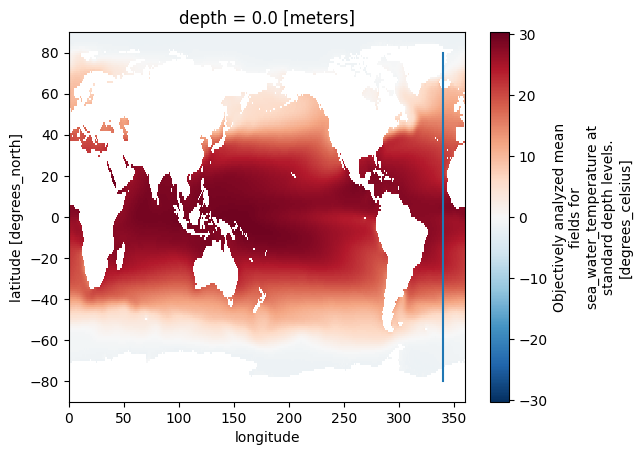

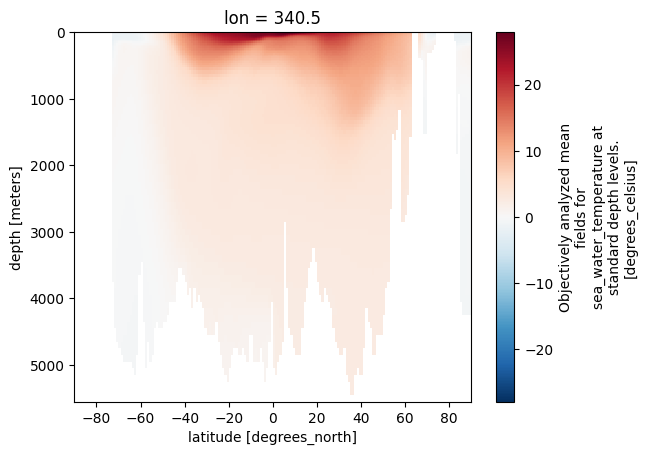

In [3]:
# 1st problem, we only take a meridional section
ds.t_an.isel(depth=0).plot(x="lon")
lon=340
plt.plot([lon,lon], [-80, 80])
plt.show()
ds = ds.isel(lon=lon)
ds.t_an.plot(yincrease=False)

In [4]:
ds["p"] = gsw.p_from_z(z=-ds["depth"], lat=ds.lat)

In [5]:
# add CT and SA
ds["SA"] = ds.gsw.SA_from_SP()

In [6]:
ds["CT"] = ds.gsw.CT_from_t()

### Create xgcm.Grid

For this, we need to create some new dimensions

1. Create new dims: lat/depth to y_c, z_c
1. Create new y_f, z_f dimensions that correspond to cell faces and add proper attributes
2. Add metrics
3. Create final grid

In [7]:
ds = generate_grid_ds(
    ds,
    {"Y":ds.cf["latitude"].name, "Z":ds.cf["depth"].name},
    position={'Y':('center','right'),'Z':('center','right')}
)

In [8]:
for xyz, lld in zip(["y","z"],["latitude","depth"]):
    ds[f"{xyz}_c"] = (ds.cf[lld].name, np.arange(ds.cf[lld].shape[0]))
    ds = ds.swap_dims({ds.cf[lld].name:f"{xyz}_c"})
    ds[f"{xyz}_f"] = (ds.cf[lld].name+"_right", np.arange(ds.cf[lld].shape[0]))
    ds = ds.swap_dims({ds.cf[lld].name+"_right":f"{xyz}_f"})
    ds[f"{xyz}_c"].attrs["axis"] = ds[ds.cf[lld].name].attrs.pop("axis")
    ds[f"{xyz}_f"].attrs["axis"] = ds[ds.cf[lld].name+"_right"].attrs.pop("axis")
    ds[f"{xyz}_f"].attrs["c_grid_axis_shift"] = ds[ds.cf[lld].name+"_right"].attrs.pop("c_grid_axis_shift")
    ds[ds.cf[lld].name+"_right"].attrs["standard_name"] = lld

In [9]:
grid = Grid(ds, periodic=["X"])
grid

<xgcm.Grid>
Z Axis (not periodic, boundary=None):
  * center   z_c --> right
  * right    z_f --> center
Y Axis (not periodic, boundary=None):
  * center   y_c --> right
  * right    y_f --> center

In [10]:
dlong = 1
dlonc = 1

dlatg =1
dlatc = 1

In [11]:
def dll_dist(dlon, dlat, lon, lat):
        """Converts lat/lon differentials into distances in meters

        PARAMETERS
        ----------
        dlon : xarray.DataArray longitude differentials
        dlat : xarray.DataArray latitude differentials
        lon  : xarray.DataArray longitude values
        lat  : xarray.DataArray latitude values

        RETURNS
        -------
        dx  : xarray.DataArray distance inferred from dlon
        dy  : xarray.DataArray distance inferred from dlat
        """

        distance_1deg_equator = 111000.0
        dx = dlon * np.cos(np.deg2rad(lat)) * distance_1deg_equator
        dy = ((lon * 0) + 1) * dlat * distance_1deg_equator
        return dx, dy

ds.coords['e1tu'], e2 = dll_dist(dlonc, dlatc, ds.lon, ds.lat)
# e1tu is at u and t points => function of y_c
ds.coords['e2'] = np.nanmean(e2)
ds.coords['e1vf'], e2 = dll_dist(dlonc, dlatc, ds.lon, ds.lat_right)
# e1vf is at v and f points => function of y_f

In [12]:
ds.coords["e3w"] = grid.diff(
    ds["depth"],
    "Z",
    boundary="fill",
    fill_value=2*ds["depth"].values[-1] - ds["depth"].values[-2]
)

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [13]:
ds.coords["e3t"] = grid.diff(
    ds["depth_right"],
    "Z",
    boundary="fill",
    fill_value=-ds["depth_right"].values[0]
)

In [14]:
ds

<xarray.Dataset> Size: 597kB
Dimensions:      (z_c: 102, y_c: 180, y_f: 180, z_f: 102)
Coordinates: (12/14)
    lat          (y_c) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    depth        (z_c) float32 408B 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon          float32 4B 340.5
    lat_right    (y_f) float32 720B -89.0 -88.0 -87.0 -86.0 ... 88.0 89.0 90.0
    depth_right  (z_f) float32 408B 2.5 7.5 12.5 ... 5.35e+03 5.45e+03 5.55e+03
  * y_c          (y_c) int64 1kB 0 1 2 3 4 5 6 7 ... 173 174 175 176 177 178 179
    ...           ...
  * z_f          (z_f) int64 816B 0 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100 101
    e1tu         (y_c) float32 720B 968.6 2.906e+03 ... 2.906e+03 968.6
    e2           float32 4B 1.11e+05
    e1vf         (y_f) float32 720B 1.937e+03 3.874e+03 ... 1.937e+03 -0.004852
    e3w          (z_f) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
    e3t          (z_c) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
Data variables:
    t_an         (z_c, y_c) float32 73kB dask.array<chunksize=(51, 90), meta=np.ndarray>
    s_an         (z_c, y_c) float32 73kB dask.array<chunksize=(51, 90), meta=np.ndarray>
    p            (z_c, y_c) float64 147kB 0.0 0.0 0.0 ... 5.632e+03 5.632e+03
    SA           (z_c, y_c) float64 147kB dask.array<chunksize=(51, 90), meta=np.ndarray>
    CT           (z_c, y_c) float64 147kB dask.array<chunksize=(51, 90), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_pract...
    summary:                         Climatological mean salinity for the glo...
    references:                      Reagan, J.R., D. Seidov, Z. Wang, D. Duk...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

### We recreate the xgcm.Grid with the new dataset

In [15]:
grid = Grid(ds, periodic=None, metrics={ "Y":["e2"], "Z":["e3t","e3w"]})
grid

<xgcm.Grid>
Z Axis (not periodic, boundary=None):
  * center   z_c --> right
  * right    z_f --> center
Y Axis (not periodic, boundary=None):
  * center   y_c --> right
  * right    y_f --> center

In [16]:
# we transpose the dataset to get (y,z) order
ds = ds.transpose(
    "y_c", "y_f", "z_c", "z_f", ...
)

## Computing reference density gradient $\vec{A}$

The density gradient is defined as:

$$
\vec{A} = \vec{\nabla} \sigma_{p_0}
$$

with $\sigma_{p_0}$ the potential density referenced locally. We transform the expression into:

$$
\vec{A} = - \alpha \vec{\nabla} \Theta + \beta \vec{\nabla} S_A
$$

So we need to compute:

#### $\alpha$ and $\beta$ at U, V, W points

we interpolate the $\alpha$ and $\beta$ from T points

#### Derivatives of $\Theta$ and $S_A$ at U, V, W points

In [17]:
dCT_dz = -grid.derivative(ds.cf["sea_water_conservative_temperature"], "Z")
# minus sign as z increases downward
dCT_dy = grid.derivative(ds.cf["sea_water_conservative_temperature"], "Y")

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [18]:
alpha = gsw.alpha(
    ds.cf["sea_water_absolute_salinity"]*0+35,
    ds.cf["sea_water_conservative_temperature"]*0+10,
    gsw.p_from_z(z=-ds.depth, lat=ds.lat)*0
)

In [19]:
alpha.mean().compute()

<xarray.DataArray 'alpha' ()> Size: 8B
array(0.00016626)
Coordinates:
    lon      float32 4B 340.5
    e2       float32 4B 1.11e+05

In [20]:
rho = 1026

In [21]:
Ay = - grid.interp(alpha, "Y") * dCT_dy * rho
Az = - grid.interp(alpha, "Z") * dCT_dz *rho

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [22]:
for v,n in zip([alpha, Ay, Az], ["alpha", "Ay", "Az"]):
    ds[n] = v
ds["alpha_y"] = grid.interp(alpha, "Y")        

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [23]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (y_c: 180, z_c: 102, y_f: 180, z_f: 102)
Coordinates: (12/14)
    lat          (y_c) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    depth        (z_c) float32 408B 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon          float32 4B 340.5
    lat_right    (y_f) float32 720B -89.0 -88.0 -87.0 -86.0 ... 88.0 89.0 90.0
    depth_right  (z_f) float32 408B 2.5 7.5 12.5 ... 5.35e+03 5.45e+03 5.55e+03
  * y_c          (y_c) int64 1kB 0 1 2 3 4 5 6 7 ... 173 174 175 176 177 178 179
    ...           ...
  * z_f          (z_f) int64 816B 0 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100 101
    e1tu         (y_c) float32 720B 968.6 2.906e+03 ... 2.906e+03 968.6
    e2           float32 4B 1.11e+05
    e1vf         (y_f) float32 720B 1.937e+03 3.874e+03 ... 1.937e+03 -0.004852
    e3w          (z_f) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
    e3t          (z_c) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
Data variables:
    t_an         (y_c, z_c) float32 73kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    s_an         (y_c, z_c) float32 73kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    p            (y_c, z_c) float64 147kB 0.0 5.054 ... 5.529e+03 5.632e+03
    SA           (y_c, z_c) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    CT           (y_c, z_c) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    alpha        (y_c, z_c) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    Ay           (y_f, z_c) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    Az           (y_c, z_f) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
    alpha_y      (y_f, z_c) float64 147kB dask.array<chunksize=(90, 51), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_pract...
    summary:                         Climatological mean salinity for the glo...
    references:                      Reagan, J.R., D. Seidov, Z. Wang, D. Duk...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

## Optimization of the surface

In [24]:
# We remove Arctic Ocean for simplicity

ds[[i for i in ds if "y_c" in ds[i].dims]] = ds[[i for i in ds if "y_c" in ds[i].dims]].where(ds.lat<65)
ds[[i for i in ds if "y_f" in ds[i].dims]] = ds[[i for i in ds if "y_f" in ds[i].dims]].where(ds.lat_right<65)

In [25]:
# we transpose the dataset to get (x,y,z) order
ds = ds.transpose(
    "y_c", "y_f", "z_c", "z_f", ...
)

### Defining the cost function

$$
J[\gamma] = \frac{1}{2}\int_V (\vec{\nabla} \gamma - \vec{\mathbf{A}})^2 \, dV
$$

In [26]:
# convert arrays jax arrays

Ay = jnp.asarray(ds.Ay)
Az = jnp.asarray(ds.Az)

e2v = jnp.asarray(ds.e2.values)
e3w = jnp.asarray(ds.e3w.values[None,:])

In [27]:
def compute_gradient(gamma, axis, e):
    """
    gamma : 2D arrays, shape (y,z)
    axis : axis on which to compute gradient, 0 for y, 1 for z
    e : scale factor
    """
    gradient = (jnp.roll(gamma, -1, axis) - gamma) / e
    # Remove boundaries
    if axis == 0:
        gradient[-1] == jnp.nan
    if axis == 1:
        gradient[:,-1] == jnp.nan
    if axis == 2:
        gradient[:,:,-1] == jnp.nan
    return gradient

In [28]:
# We define masks so the A is not NaNs at the boundaries

vmask = jnp.where(
    jnp.isfinite(
        compute_gradient((ds.SA*0+1).values, 0, 1.)
    ),
    1,
    0
)

wmask = jnp.where(
    jnp.isfinite(
        compute_gradient((ds.SA*0+1).values, 1, 1.)
    ),
    1,
    0
)


$$
J[\gamma] = \frac{1}{2}\int_V (\vec{\nabla} \gamma - \vec{\mathbf{A}})^2 \, dV
$$

In [29]:
def floss(gamma):
    """Loss function"""
    grad_V = jnp.nan_to_num(
        compute_gradient(gamma, axis=0, e=e2v)
    )
    grad_W = -jnp.nan_to_num(
        compute_gradient(gamma, axis=1, e=e3w)
    )
    diff_V1 = (jnp.roll((grad_V - Ay), -1, 0) + (grad_V - Ay))/2
    diff_V2 = (jnp.roll((grad_V - Ay), -1, 1) + (grad_V - Ay))/2
    diff_W1 = (jnp.roll((grad_W - Az), -1, 1) + (grad_W - Az))/2
    diff_W2 = (jnp.roll((grad_W - Az), -1, 0) + (grad_W - Az))/2

    return 1e5*jnp.nansum(
        (grad_V - Ay)**2 * vmask*3e5 + (grad_W - Az)**2 * wmask
    ) # not weighted integral

    # we should add a regularization to ensure "smoothness" of the solution
    # otherwise, the gradient shows grid noise
    
    return 1e5*jnp.nansum(
        diff_V1**2 * vmask + diff_W1**2 * wmask + diff_V2**2 * vmask + diff_W2**2 * wmask
    ) # not weighted integral
    

In [30]:
ds.Ay.mean().compute() / ds.Az.mean().compute()

<xarray.DataArray ()> Size: 8B
array(3.42289985e-05)
Coordinates:
    lon      float32 4B 340.5
    e2       float32 4B 1.11e+05

In [31]:
def floss_xr(gamma):
    gamma_jax = jnp.asarray(gamma.transpose("y_c","z_c").values)
    return floss(gamma_jax)

In [32]:
tests_gammas = {
    "rho": ds.gsw.rho(),
    "sigma0": ds.gsw.sigma0(),
    "sigma2": ds.gsw.sigma2(),
    "constant": ds.CT*0,
    "linear eos temperature": -ds.CT*ds.alpha*1026,
    "linear eos temperature smoothed": (-ds.CT*ds.alpha*1026).fillna(0).rolling(y_c=5).mean(),
    "linear eos temperature noise": -ds.CT*ds.alpha*1026 + ds.CT.isel(y_c=80)*ds.alpha*1026/1000,
    "linear eos temperature mean profile": ds.CT*0-ds.CT.mean("y_c")*ds.alpha*1026,
    "linear eos temperature eq profile": ds.CT*0-ds.CT.isel(y_c=80)*ds.alpha*1026,
}

In [33]:
for i in tests_gammas.keys():
    print(i, ", loss : ", floss_xr(tests_gammas[i]))

rho , loss :  44279.438
sigma0 , loss :  13816.552
sigma2 , loss :  19807.145
constant , loss :  33186.46
linear eos temperature , loss :  1.2937085e-07
linear eos temperature smoothed , loss :  1514.4177
linear eos temperature noise , loss :  0.18782468
linear eos temperature mean profile , loss :  19812.031
linear eos temperature eq profile , loss :  39685.06


In [34]:
# ok so it seems that the A vector already has a very small norm

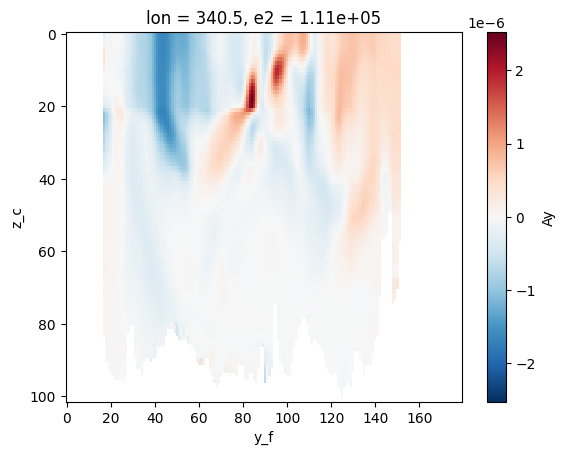

In [35]:
ds.Ay.plot(y="z_c", yincrease=False)

In [36]:
gamma = jnp.asarray(tests_gammas["linear eos temperature"].transpose("y_c","z_c").values)

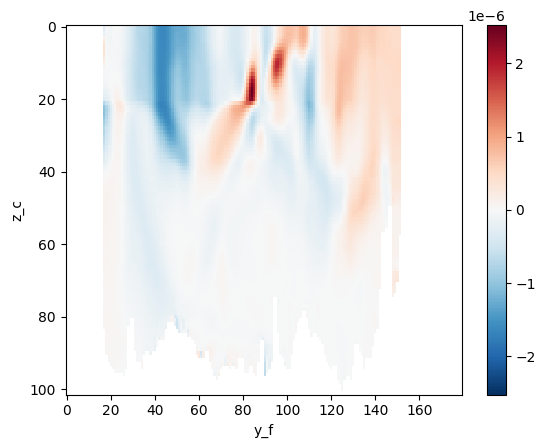

In [37]:
xr.DataArray(jnp.nan_to_num(
        compute_gradient(gamma, axis=0, e=e2v)
    ), dims=("y_f", "z_c")).where(vmask).plot(y="z_c", yincrease=False)

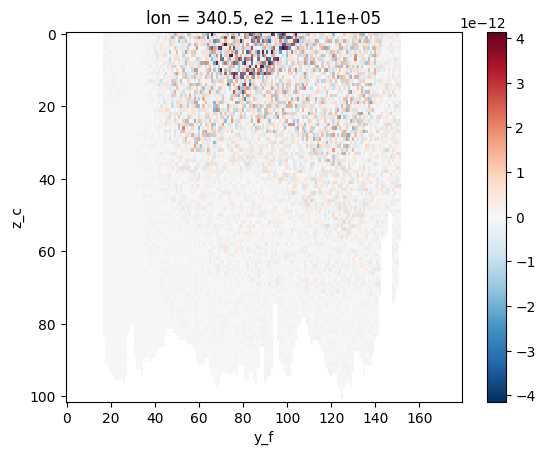

In [38]:
(ds.Ay - xr.DataArray(np.array(jnp.nan_to_num(
        compute_gradient(gamma, axis=0, e=e2v)
    )), dims=("y_f", "z_c")).where(np.array(vmask))).plot(y="z_c", yincrease=False)

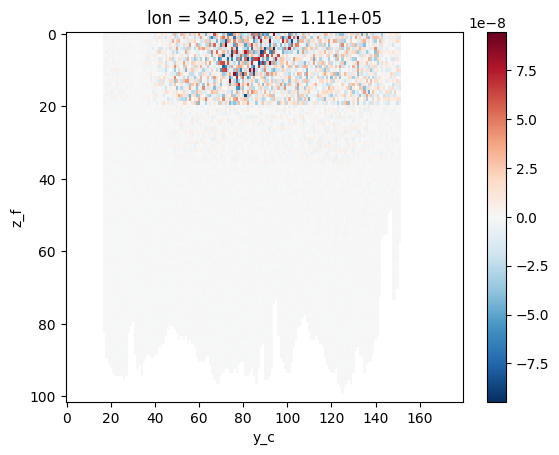

In [39]:
(ds.Az - xr.DataArray(-np.array(jnp.nan_to_num(
        compute_gradient(gamma, axis=1, e=e3w)
    )), dims=("y_c", "z_f")).where(np.array(vmask))).plot(y="z_f", yincrease=False)

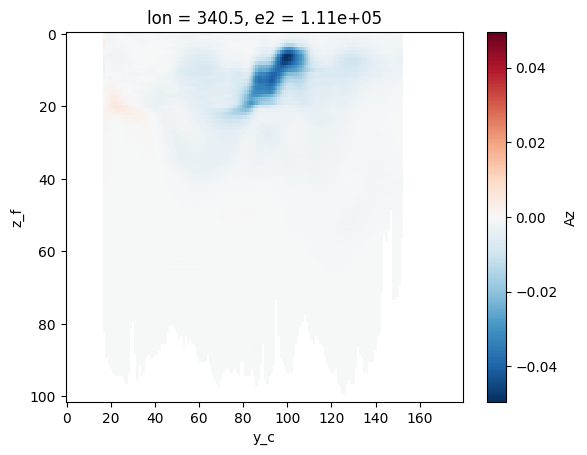

In [40]:
ds.Az.plot(y="z_f", yincrease=False)

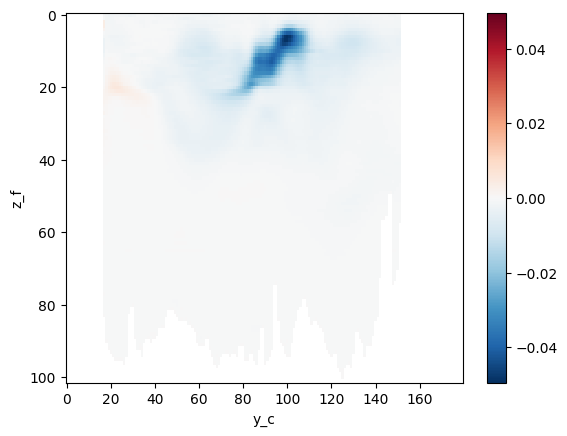

In [41]:
(xr.DataArray(-np.array(jnp.nan_to_num(
        compute_gradient(gamma, axis=1, e=e3w)
    )), dims=("y_c", "z_f")).where(np.array(vmask))).plot(y="z_f", yincrease=False)

In [42]:
initial_gamma = jnp.asarray(tests_gammas["linear eos temperature smoothed"].transpose("y_c","z_c").values)

In [43]:
#initial_gamma = jnp.asarray(tests_gammas["constant"].transpose("y_c","z_c").values)

In [44]:
floss(initial_gamma)

Array(1514.4177, dtype=float32)

### Optimization

In [45]:
grad_loss = jax.grad(floss)

def train(params, learning_rate=0.01, num_steps=1000):
    """Train using gradient descent optimization"""
    # Define optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    losses = []
    
    for step in range(num_steps):
        # Compute loss and gradients
        loss = floss(params)
        #grads = jnp.nan_to_num(grad_loss(params))
        grads = grad_loss(params)
        
        losses.append(loss)
        
        # Apply updates
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step {step+1}, Loss: {loss}")
            plt.imshow(params[:,:].T)
            plt.show()
    
    return params, losses

In [46]:
jnp.nanmax(initial_gamma)

Array(0.3020067, dtype=float32)

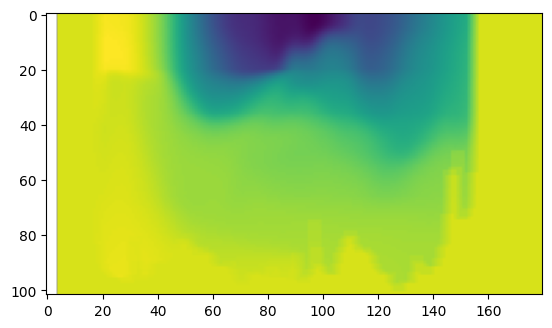

In [47]:
plt.imshow(initial_gamma[:,:].T)

In [48]:
g = grad_loss(initial_gamma)

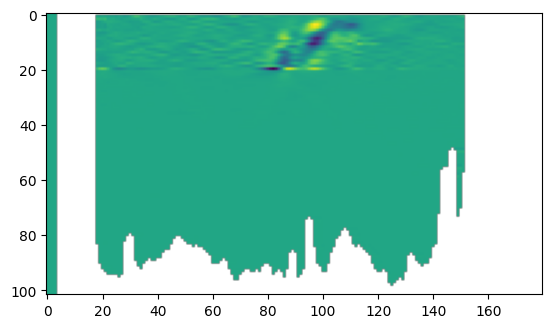

In [49]:
plt.imshow(g.T)

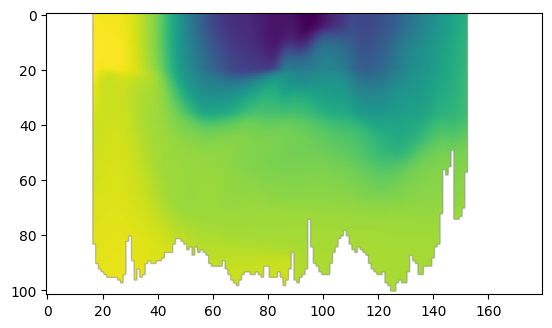

In [50]:
plt.imshow(-ds.alpha.values.T*1026*ds.CT.values[:,:].T)

Step 1, Loss: 33186.4609375


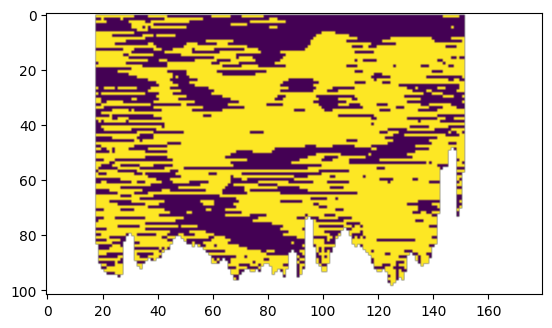

Step 101, Loss: 2425.073486328125


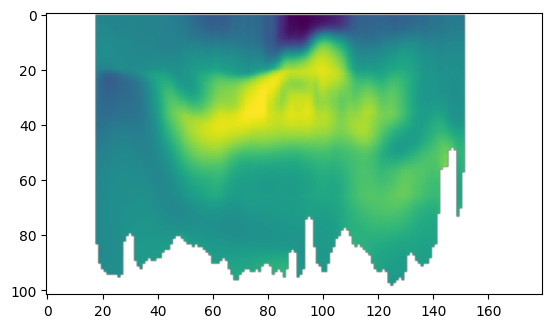

Step 201, Loss: 736.3604125976562


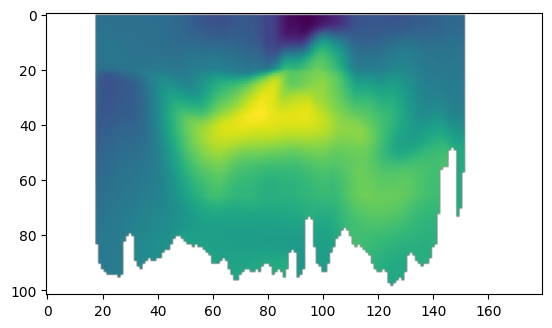

Step 301, Loss: 349.391845703125


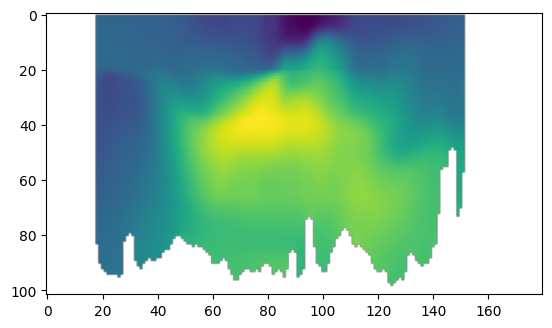

Step 401, Loss: 202.96417236328125


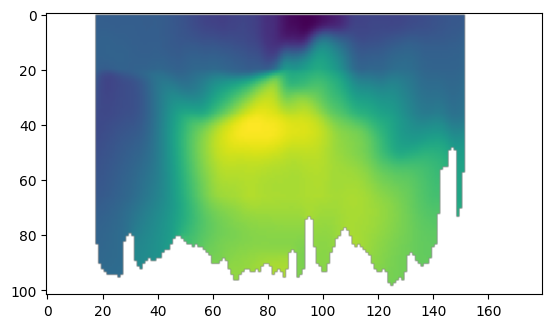

Step 501, Loss: 148.47576904296875


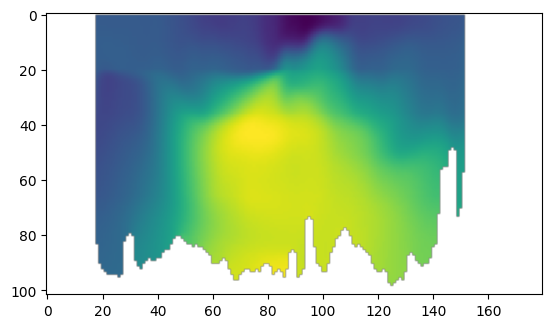

Step 601, Loss: 129.93017578125


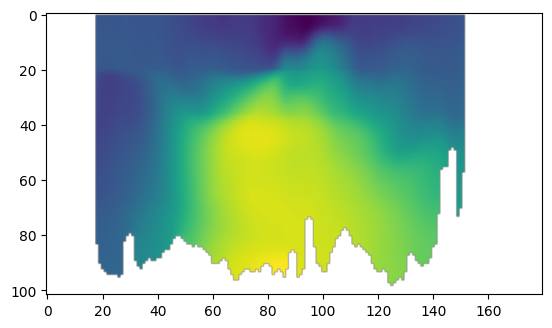

Step 701, Loss: 123.70052337646484


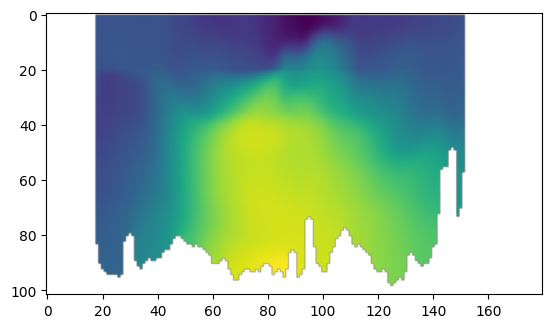

Step 801, Loss: 121.78671264648438


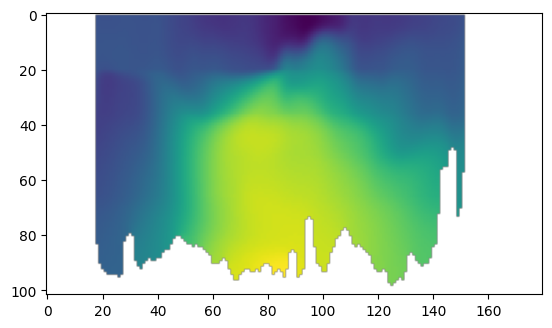

Step 901, Loss: 119.77855682373047


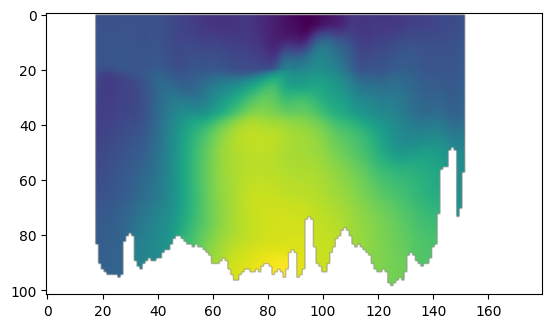

Step 1001, Loss: 118.13007354736328


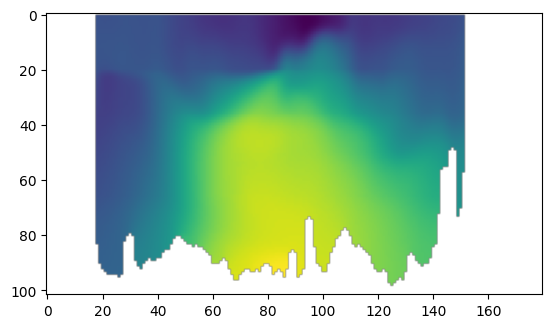

Step 1101, Loss: 117.59700775146484


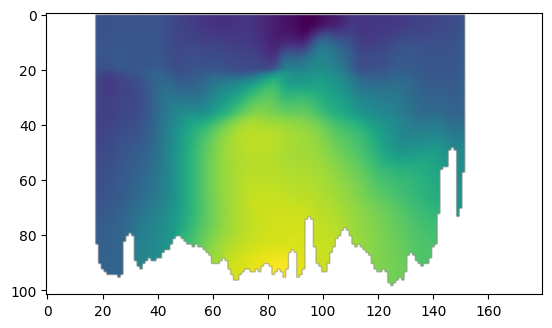

Step 1201, Loss: 115.98944091796875


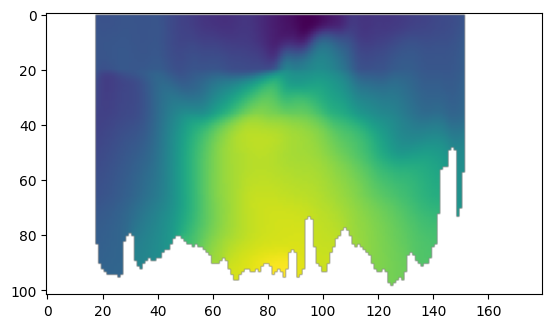

Step 1301, Loss: 115.14627838134766


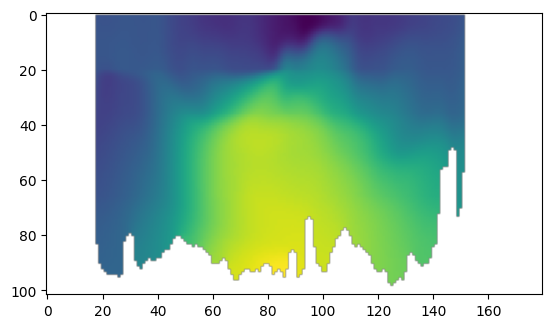

Step 1401, Loss: 112.767333984375


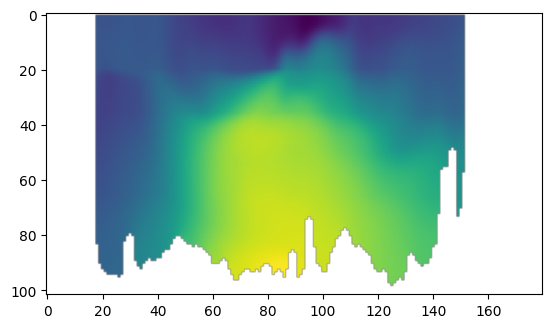

Step 1501, Loss: 112.98477172851562


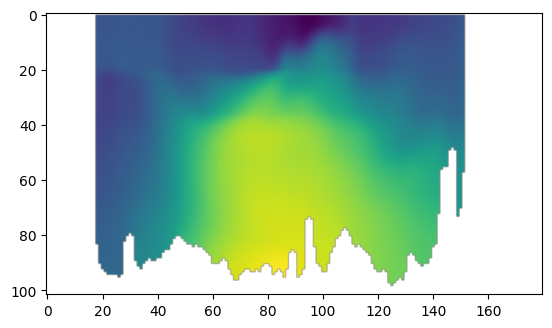

Step 1601, Loss: 111.46955871582031


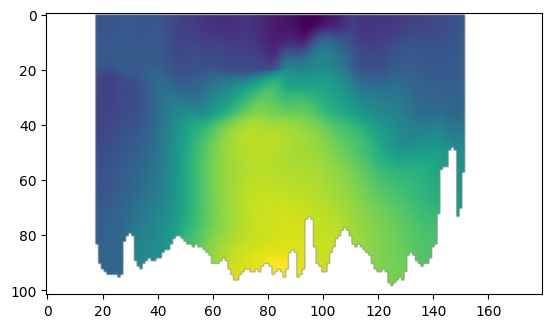

Step 1701, Loss: 111.47314453125


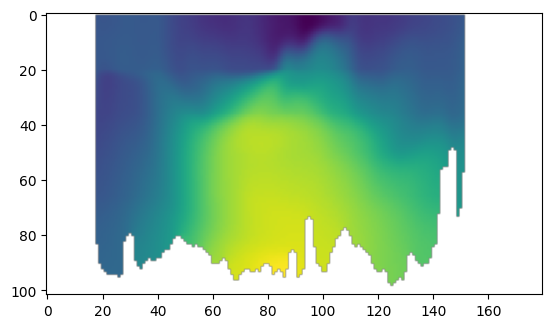

Step 1801, Loss: 108.25773620605469


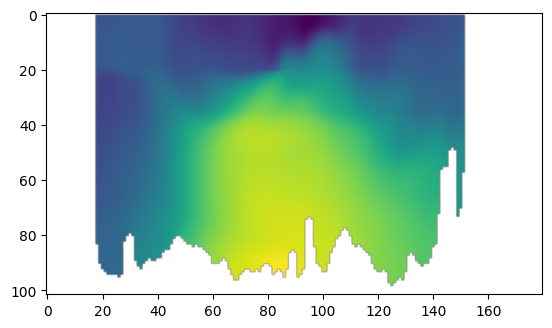

Step 1901, Loss: 108.38851165771484


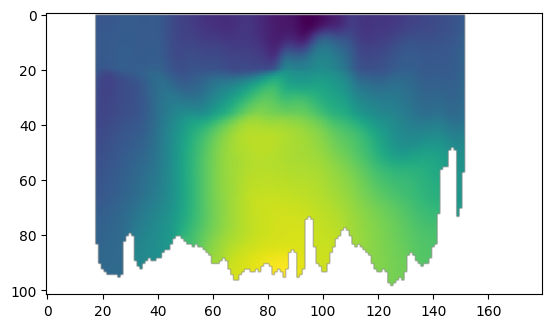

Optimization complete!
Initial loss: 1514.417724609375
Final loss: 107.7337646484375


In [51]:
   
# Run optimization
optimal_gamma, loss_history = train(
    initial_gamma*0, 
    learning_rate=.01, 
    num_steps=2000
)

print("Optimization complete!")
print(f"Initial loss: {floss(initial_gamma)}")
print(f"Final loss: {floss(optimal_gamma)}")

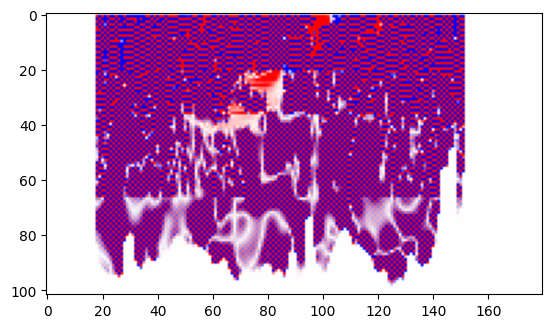

In [52]:
plt.imshow(grad_loss(optimal_gamma).T,  cmap="bwr",vmin=-0.01,vmax=0.01)

In [53]:
optimizer = optax.adam(0.000001)
opt_state = optimizer.init(optimal_gamma)
grads = grad_loss(optimal_gamma)
updates, opt_state = optimizer.update(grads, opt_state)
params = optax.apply_updates(optimal_gamma, updates)

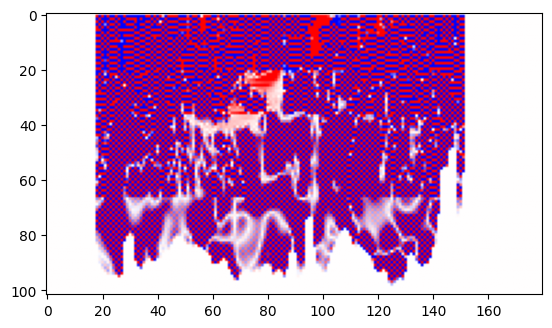

In [54]:
plt.imshow(grad_loss(params).T,  cmap="bwr",vmin=-0.01,vmax=0.01)

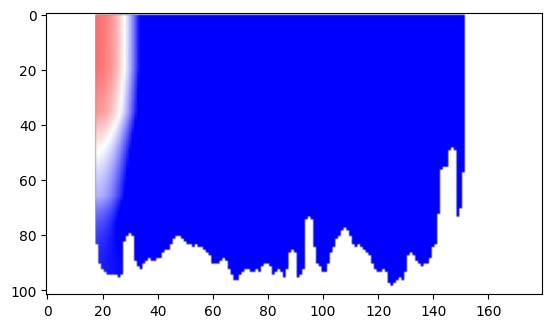

In [55]:
plt.imshow((-ds.CT.values*ds.alpha.values*1026-optimal_gamma).T, cmap="bwr", vmin=-.3,vmax=.3)

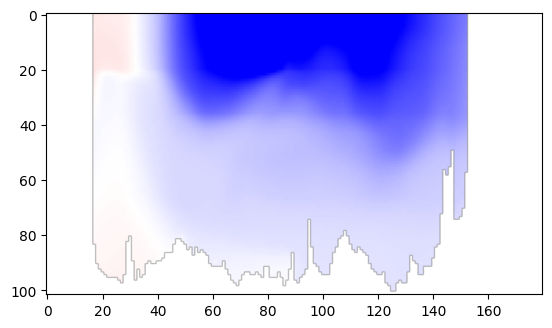

In [56]:
plt.imshow((-ds.CT.values*ds.alpha.values*1026-initial_gamma*0).T, cmap="bwr", vmin=-3,vmax=3)

In [57]:
jnp.nanmax(-ds.CT.values*ds.alpha.values*1026-optimal_gamma)

Array(0.16738866, dtype=float32)